In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize 
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

True mixture parameters:
  Component 1: weight=0.30, μ=-2.0, σ=0.8
  Component 2: weight=0.50, μ=1.0, σ=1.2
  Component 3: weight=0.20, μ=4.0, σ=0.6


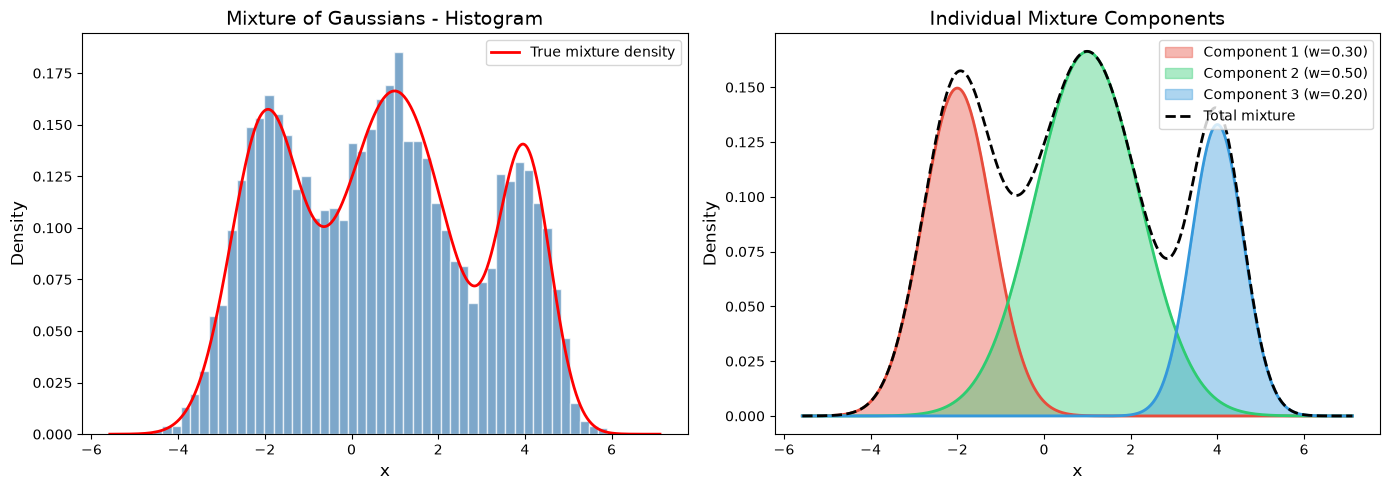

In [2]:
def sample_gaussian_mixture(n_samples, weights, means, stds):
    weights = np.array(weights)
    K = len(weights)
   
    # Assign each sample to a component
    component_labels = np.random.choice(K, size=n_samples, p=weights)
   
    # Sample from the assigned component
    samples = np.array([
        np.random.normal(means[c], stds[c])
        for c in component_labels
    ])
   
    return samples, component_labels


# True mixture parameters
TRUE_WEIGHTS = [0.3, 0.5, 0.2]  # 3 components
TRUE_MEANS = [-2.0, 1.0, 4.0]
TRUE_STDS = [0.8, 1.2, 0.6]

n_samples = 5000
data, labels = sample_gaussian_mixture(n_samples, TRUE_WEIGHTS, TRUE_MEANS, TRUE_STDS)

print("True mixture parameters:")
for k in range(len(TRUE_WEIGHTS)):
    print(f"  Component {k+1}: weight={TRUE_WEIGHTS[k]:.2f}, μ={TRUE_MEANS[k]:.1f}, σ={TRUE_STDS[k]:.1f}")

# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with true density overlay
x_grid = np.linspace(data.min() - 1, data.max() + 1, 500)
true_density = sum(
    w * stats.norm.pdf(x_grid, m, s)
    for w, m, s in zip(TRUE_WEIGHTS, TRUE_MEANS, TRUE_STDS)
)

axes[0].hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].plot(x_grid, true_density, 'r-', linewidth=2, label='True mixture density')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Mixture of Gaussians - Histogram', fontsize=14)
axes[0].legend()

# Individual components
colors = ['#e74c3c', '#2ecc71', '#3498db']
for k in range(len(TRUE_WEIGHTS)):
    component_density = TRUE_WEIGHTS[k] * stats.norm.pdf(x_grid, TRUE_MEANS[k], TRUE_STDS[k])
    axes[1].fill_between(x_grid, component_density, alpha=0.4, color=colors[k],
                          label=f'Component {k+1} (w={TRUE_WEIGHTS[k]:.2f})')
    axes[1].plot(x_grid, component_density, color=colors[k], linewidth=2)

axes[1].plot(x_grid, true_density, 'k--', linewidth=2, label='Total mixture')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Individual Mixture Components', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()